# Example I: Search problem 

## 1. Problem Introduction

Modern warehouses are increasingly adopting autonomous robotic systems to improve the efficiency, speed, and reliability of material handling and order fulfilment. Technologies such as Autonomous Mobile Robots (AMRs), Automated Guided Vehicles (AGVs), and Goods-to-Person (G2P) systems are used to transport products, shelves, bins, and other materials throughout warehouse environments. These systems reduce the need for workers to manually travel long distances across large warehouse facilities and can help streamline the movement of goods from storage areas to picking and packing stations.

Unlike traditional fixed-path systems, many modern autonomous warehouse robots use sensors, maps, and navigation algorithms to understand their surroundings, avoid obstacles, and determine suitable paths to their destinations. For example, in a G2P system, a robot may navigate through a warehouse, locate a required storage shelf or bin, and transport it directly to a stationary human worker at a picking station. As warehouses become larger and more complex, determining an efficient route for these robots becomes increasingly important.

The problem considered in this project is therefore a warehouse robot path-planning and route optimisation problem. An autonomous warehouse robot must navigate from a designated starting or loading area to a product-picking station or required product location within a simplified warehouse layout. The warehouse can be represented as a network of connected locations, where different routes may have different travel costs based on factors such as distance, time, energy consumption, congestion, or other operational considerations.

The primary objective is to determine a minimum-cost route between the robot's starting location and its required destination. Rather than simply finding any feasible path, the system aims to identify the most efficient route while considering the costs associated with travelling through different sections of the warehouse.

By modelling the warehouse as a graph and applying appropriate path-finding and optimisation techniques, we aim to investigate how autonomous warehouse robots can efficiently determine their routes. Finding effective solutions to this problem can help reduce unnecessary travel, lower operational costs, improve delivery and picking times, and ultimately contribute to more efficient and scalable autonomous warehouse operations.

## 2. Problem Definition

### Problem Definition

Finding an efficient route for an autonomous warehouse robot through a warehouse environment is a fundamental **path-planning and optimisation problem** in operations research and logistics. In this project, the warehouse is represented as a simplified graph consisting of locations (nodes) and connecting routes (edges), with each route assigned a travel cost. The robot must navigate from a designated starting point to a specific product or picking location while avoiding unnecessary travel and minimising the total cost of the journey.

The problem can be formulated as a **minimum-cost path-finding problem**, where the objective is to determine the least-cost sequence of routes connecting the robot's starting location to its required destination. This provides a simplified representation of the navigation challenges faced by autonomous warehouse systems such as AMRs, AGVs, and G2P robots.

To investigate this problem, the project focuses on two fundamental artificial intelligence search techniques: **Uniform Cost Search (UCS)** and **A* Search**. UCS determines the optimal path by expanding the lowest-cost path discovered so far, while A* combines the cost already incurred with a heuristic estimate of the remaining cost to guide the search towards the destination.

Therefore, the central research question of this project is:

> **How effectively can Uniform Cost Search and A* Search determine a minimum-cost navigation path for an autonomous warehouse robot, and which technique provides a better balance between solution cost and search efficiency?*

The performance of the two approaches will be evaluated based on factors such as **path cost, search efficiency, number of nodes explored, and computational effort**. This comparison will provide insight into the trade-off between guaranteeing an optimal solution and efficiently navigating the search space in an autonomous warehouse environment.


## 3. Warehouse State-Space Design

[Reference of warehouse layout](https://www.researchgate.net/figure/Graph-representation-of-the-warehouse_fig8_374910922)

![Base layout](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQig8wD86vGIufgkNhsFv-usHG1jaUkFhSPQt7boS_9lG7z15wzjZEGn9v9&s=10)

![Example layout](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTi-50Vx_JW3G_bH_HqaatqcaeKFTKB0_b9bEqPQmz8aQ&s=10)

### 3.1 Simplied layout

for this simplified layout we will be using:

- 5 vertical aisles
- 4 horizontal cross-aisles
- 20 major intersection states
- 1 starting location
- 1 destination
- All connections are weighted
- some higher-cost/congested sections

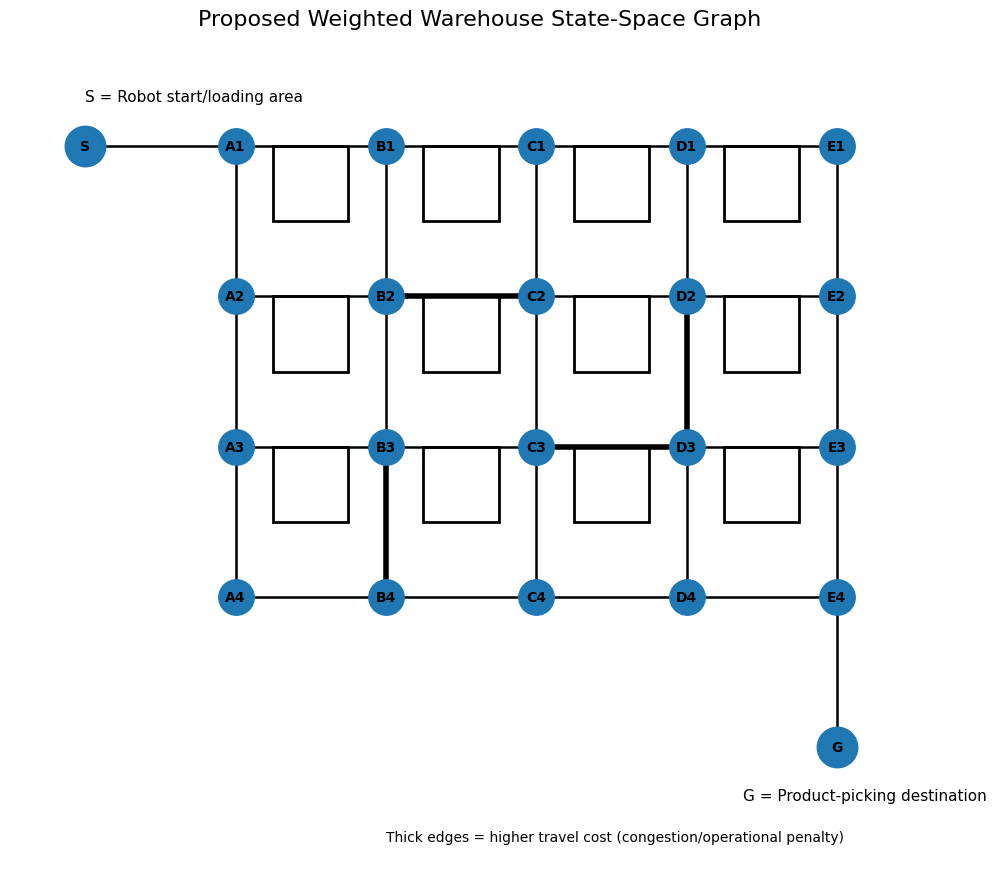

Saved graph image: C:/Users/srian/Desktop/warehouse_state_space_graph.png
Saved edge list: C:/Users/srian/Desktop/warehouse_edges.csv

Edge list:


,from,to,cost
0,A1,B1,4
1,A1,A2,4
2,A1,S,4
3,B1,C1,4
4,B1,B2,4
5,C1,D1,4
6,C1,C2,4
7,D1,E1,4
8,D1,D2,4
9,E1,E2,4


In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import math

# Warehouse state coordinates used by the search problem.
coords = {
    "S": (-4, 12),
    "A1": (0, 12), "B1": (4, 12), "C1": (8, 12), "D1": (12, 12), "E1": (16, 12),
    "A2": (0, 8),  "B2": (4, 8),  "C2": (8, 8),  "D2": (12, 8),  "E2": (16, 8),
    "A3": (0, 4),  "B3": (4, 4),  "C3": (8, 4),  "D3": (12, 4),  "E3": (16, 4),
    "A4": (0, 0),  "B4": (4, 0),  "C4": (8, 0),  "D4": (12, 0),  "E4": (16, 0),
    "G": (16, -4)
}

G = nx.Graph()

# Base horizontal and vertical travel costs.
for r in range(1, 5):
    for c in range(4):
        u = "ABCDE"[c] + str(r)
        v = "ABCDE"[c + 1] + str(r)
        G.add_edge(u, v, weight=4)

for c in range(5):
    for r in range(1, 4):
        u = "ABCDE"[c] + str(r)
        v = "ABCDE"[c] + str(r + 1)
        G.add_edge(u, v, weight=4)

G.add_edge("S", "A1", weight=4)
G.add_edge("E4", "G", weight=4)

# Higher-cost sections representing congestion/operational penalties.
penalties = {
    ("B2", "C2"): 8,
    ("C3", "D3"): 10,
    ("D2", "D3"): 7,
    ("B3", "B4"): 7,
}
for (u, v), cost in penalties.items():
    G[u][v]["weight"] = cost

# Draw the warehouse layout with racks shown between the travel lanes.
fig, ax = plt.subplots(figsize=(14, 9))

# Storage rack blocks
for x in [1, 5, 9, 13]:
    for y in [10, 6, 2]:
        ax.add_patch(plt.Rectangle((x, y), 2, 2, fill=False, linewidth=2))

# Graph edges
nx.draw_networkx_edges(G, coords, ax=ax, width=1.8)

# Nodes
nx.draw_networkx_nodes(
    G, coords, ax=ax,
    nodelist=[n for n in G.nodes if n not in ["S", "G"]],
    node_size=650
)
nx.draw_networkx_nodes(G, coords, ax=ax, nodelist=["S", "G"], node_size=850)

# Labels
nx.draw_networkx_labels(G, coords, ax=ax, font_size=10, font_weight="bold")

# Mark higher-cost edges
nx.draw_networkx_edges(
    G, coords, ax=ax,
    edgelist=list(penalties.keys()),
    width=4
)

ax.set_title("Proposed Weighted Warehouse State-Space Graph", fontsize=16)
ax.text(-4, 13.2, "S = Robot start/loading area", fontsize=11)
ax.text(13.5, -5.4, "G = Product-picking destination", fontsize=11)
ax.text(4, -6.5, "Thick edges = higher travel cost (congestion/operational penalty)", fontsize=10)

ax.set_xlim(-6, 19)
ax.set_ylim(-7.5, 15)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

graph_path = "C:/Users/srian/Desktop/warehouse_state_space_graph.png"
plt.savefig(graph_path, dpi=200, bbox_inches="tight")
plt.show()

# Export the edge list for convenient use in Colab.
edge_rows = []
for u, v, data in G.edges(data=True):
    edge_rows.append({
        "from": u,
        "to": v,
        "cost": data["weight"]
    })

edge_df = pd.DataFrame(edge_rows)
csv_path = "C:/Users/srian/Desktop/warehouse_edges.csv"
edge_df.to_csv(csv_path, index=False)

print(f"Saved graph image: {graph_path}")
print(f"Saved edge list: {csv_path}")
print("\nEdge list:")
display(edge_df)


-------------------

In [14]:
# Import the libraries required to construct, visualise and search
# the weighted warehouse state-space graph.

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import heapq
import time

In [15]:
# Each state is assigned a coordinate so that A* can estimate
# the remaining distance to the goal.

cities = {
    'S': (-4, 12),

    'A1': (0, 12),
    'B1': (4, 12),
    'C1': (8, 12),
    'D1': (12, 12),
    'E1': (16, 12),

    'A2': (0, 8),
    'B2': (4, 8),
    'C2': (8, 8),
    'D2': (12, 8),
    'E2': (16, 8),

    'A3': (0, 4),
    'B3': (4, 4),
    'C3': (8, 4),
    'D3': (12, 4),
    'E3': (16, 4),

    'A4': (0, 0),
    'B4': (4, 0),
    'C4': (8, 0),
    'D4': (12, 0),
    'E4': (16, 0),

    'G': (16, -4)
}

In [16]:
G = nx.Graph()

# Add nodes and their coordinates
G.add_nodes_from(cities.keys())

# Add weighted edges
warehouse_edges = [
    ('S', 'A1', 4),

    ('A1', 'B1', 4),
    ('B1', 'C1', 4),
    ('C1', 'D1', 4),
    ('D1', 'E1', 4),

    ('A1', 'A2', 4),
    ('B1', 'B2', 4),
    ('C1', 'C2', 4),
    ('D1', 'D2', 4),
    ('E1', 'E2', 4),

    ('A2', 'B2', 4),
    ('B2', 'C2', 4),
    ('C2', 'D2', 4),
    ('D2', 'E2', 4),

    ('A2', 'A3', 4),
    ('B2', 'B3', 4),
    ('C2', 'C3', 4),
    ('D2', 'D3', 4),
    ('E2', 'E3', 4),

    ('A3', 'B3', 4),
    ('B3', 'C3', 4),
    ('C3', 'D3', 4),
    ('D3', 'E3', 4),

    ('A3', 'A4', 4),
    ('B3', 'B4', 4),
    ('C3', 'C4', 4),
    ('D3', 'D4', 4),
    ('E3', 'E4', 4),

    ('A4', 'B4', 4),
    ('B4', 'C4', 4),
    ('C4', 'D4', 4),
    ('D4', 'E4', 4),

    ('E4', 'G', 4)
]

G.add_weighted_edges_from(warehouse_edges)

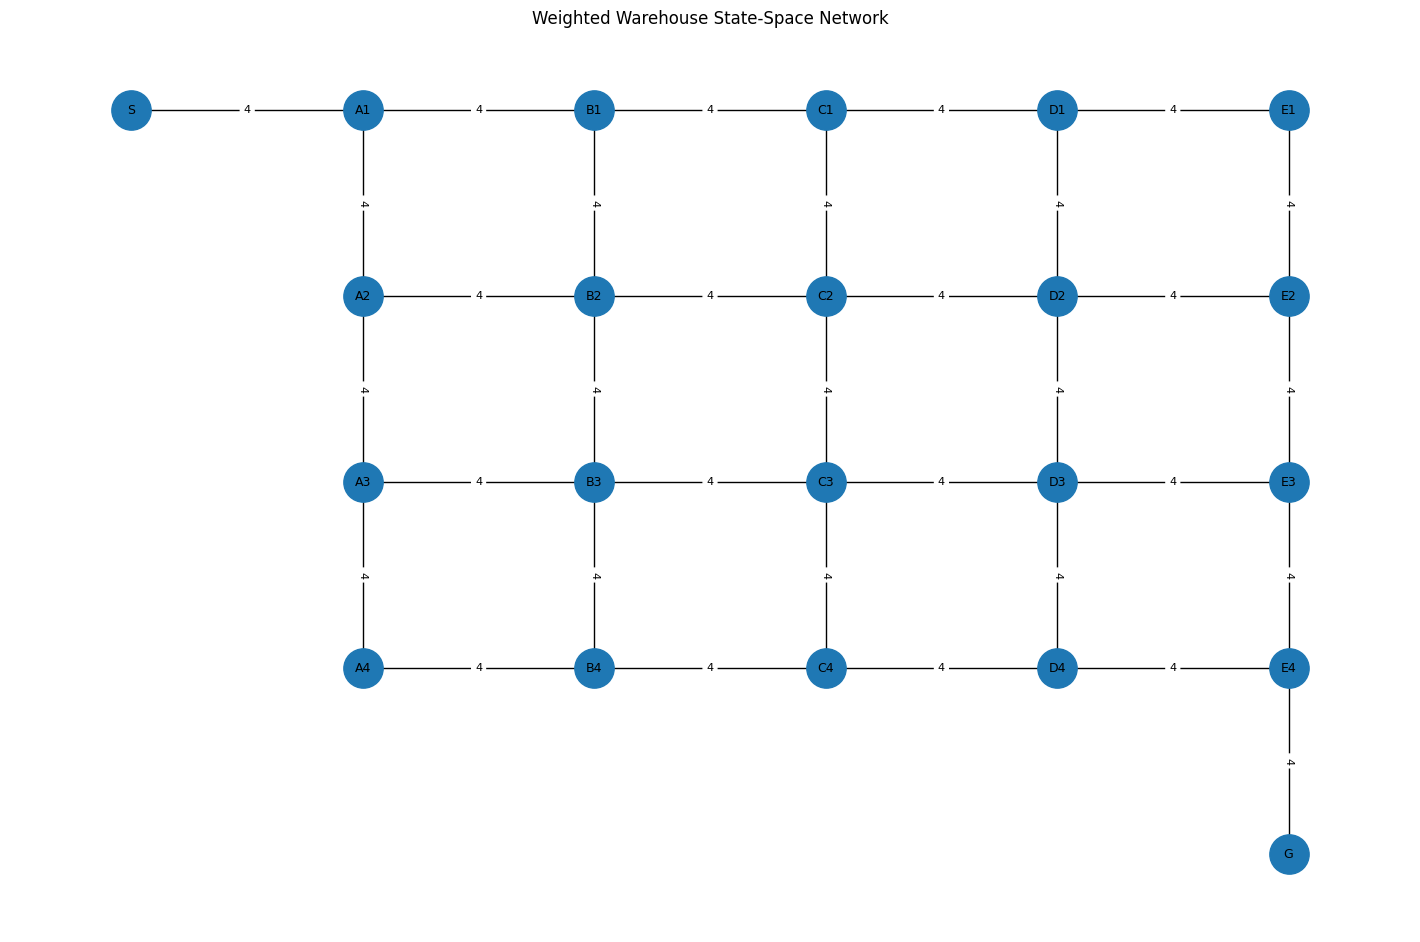

In [ ]:
plt.figure(figsize=(14, 9))

nx.draw(
    G,
    cities,
    with_labels=True,
    node_size=800,
    font_size=9
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    cities,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Weighted Warehouse State-Space Network")
plt.axis("off")
plt.show()

In [18]:
print("Number of states:", len(G.nodes))
print("Number of edges:", len(G.edges))

Number of states: 22
Number of edges: 33


In [20]:
# Define the initial state and the destination state
# for the warehouse navigation problem.

source = 'S'
goal = 'G'

print('The start state is: {}'.format(source))
print('The goal state is: {}'.format(goal))

The start state is: S
The goal state is: G


### Euclidean heuristic

## 4. UCS

## 5. A*

## 6. Results

## 7. Comparison

## 8. Recommendation